<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/Bank_Data_Dimensionality_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load the bank marketing dataset

We'll use a publicly available bank marketing dataset (`bank-additional-full.csv`) for this task. First, we need to download it and load it into a pandas DataFrame.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# URL for the dataset
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
zip_file_name = "bank-additional.zip"
csv_file_name = "bank-additional/bank-additional-full.csv"

# Download the zip file if it doesn't exist
import os
if not os.path.exists(zip_file_name):
    print("Downloading dataset...")
    import urllib.request
    urllib.request.urlretrieve(dataset_url, zip_file_name)
    print("Download complete.")

# Unzip the file and load the CSV
import zipfile
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(".")

# Load the dataset (it's semicolon-separated)
df = pd.read_csv(csv_file_name, sep=';')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

Download complete.
First 5 rows of the dataset:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Preprocessing the data

Before applying dimensionality reduction techniques like PCA and t-SNE, we need to preprocess the data. This involves:
1.  **Separating features and target**: We'll use all columns except the target variable `y` (which indicates if the client subscribed to a term deposit) as features.
2.  **Handling categorical variables**: One-hot encoding.
3.  **Handling numerical variables**: Standard scaling.

We'll use `ColumnTransformer` and `Pipeline` for efficient preprocessing.

In [2]:
# Separate features (X) and target (y)
X = df.drop('y', axis=1)
y = df['y'].apply(lambda x: 1 if x == 'yes' else 0) # Convert 'yes'/'no' to 1/0

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create a preprocessing pipeline
preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Fit and transform the data
X_preprocessed = preprocessing_pipeline.fit_transform(X)

print(f"Original number of features: {X.shape[1]}")
print(f"Number of features after preprocessing: {X_preprocessed.shape[1]}")
print("Shape of preprocessed data:", X_preprocessed.shape)

Original number of features: 20
Number of features after preprocessing: 63
Shape of preprocessed data: (41188, 63)


### Apply PCA (Principal Component Analysis)

PCA is a linear dimensionality reduction technique that transforms the data to a new coordinate system such that the greatest variance by some projection of the data comes to lie on the first principal component, the second greatest variance on the second principal component, and so on. We'll reduce the data to 2 components.

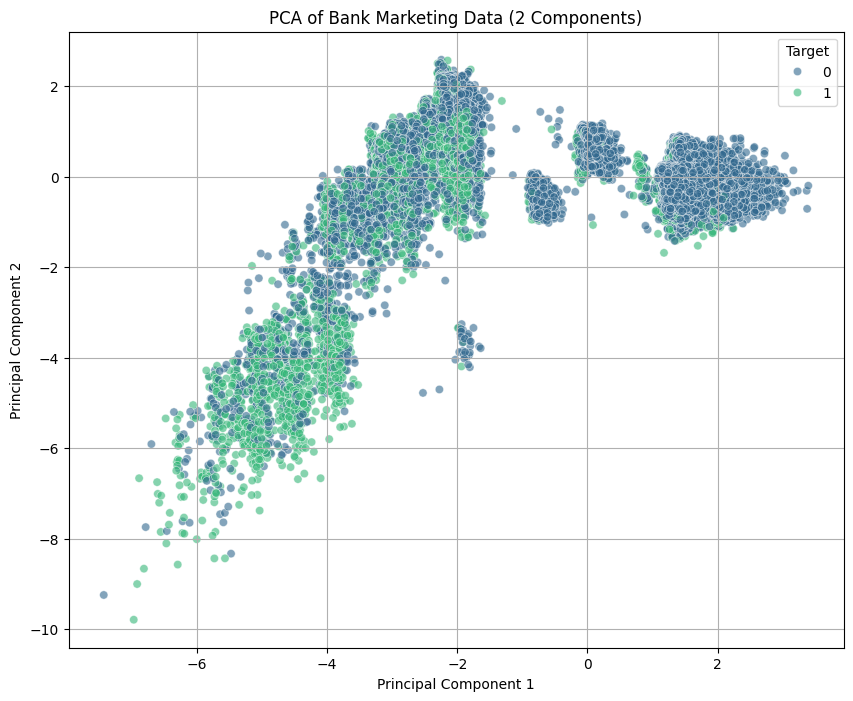

In [3]:
# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_preprocessed)

# Create a DataFrame for visualization
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Target'] = y

# Visualize PCA results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Target',
    palette='viridis',
    data=pca_df,
    alpha=0.6
)
plt.title('PCA of Bank Marketing Data (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### Apply t-SNE (t-Distributed Stochastic Neighbor Embedding)

t-SNE is a non-linear dimensionality reduction technique well-suited for visualizing high-dimensional datasets. It maps multi-dimensional data to a lower-dimensional space (e.g., 2D or 3D) such that similar points are modeled by nearby points and dissimilar points are modeled by distant points with high probability. We'll reduce the data to 2 components.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


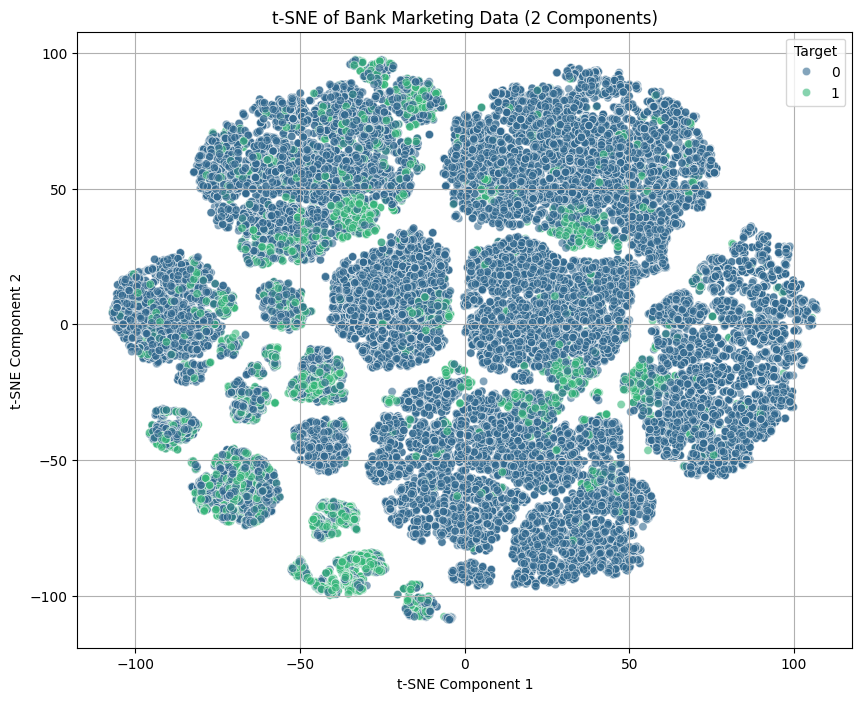

In [4]:
# Apply t-SNE to reduce dimensions to 2
# Note: t-SNE can be computationally intensive for large datasets.
# Consider using a smaller subset or a faster variant if performance is an issue.
# We'll use a random state for reproducibility.
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_preprocessed)

# Create a DataFrame for visualization
tsne_df = pd.DataFrame(data=X_tsne, columns=['t-SNE Component 1', 't-SNE Component 2'])
tsne_df['Target'] = y

# Visualize t-SNE results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='t-SNE Component 1',
    y='t-SNE Component 2',
    hue='Target',
    palette='viridis',
    data=tsne_df,
    alpha=0.6
)
plt.title('t-SNE of Bank Marketing Data (2 Components)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()